# SENSEI — Session Intelligence
## Module 2 · Purchase Prediction — Classification

Binary classification on the session feature store built in Module 1.
Target: `purchased` (1 = session contains a transaction). Purchase rate: 0.81 % — imbalance ratio ~1:122.

## Contents
1. Load feature store & train/test split
2. Logistic Regression (baseline)
3. Random Forest
4. Evaluation: normalized confusion matrix + PR curve
5. Cross-validation (5-fold stratified)
6. Permutation feature importance
7. Threshold tuning

## Summary

| | |
|---|---|
| Models | Logistic Regression (baseline), Random Forest |
| Imbalance handling | `class_weight='balanced'` |
| Primary metrics | PR-AUC, F1 — not accuracy |
| CV | 5-fold stratified |
| Feature importance | Permutation (unbiased vs. MDI) |
| Threshold | Tuned to maximise F1 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    f1_score,
    ConfusionMatrixDisplay,
)

sns.set_theme(style='whitegrid', palette='muted')
DATA_DIR = os.path.join('..', 'data')
RANDOM_STATE = 42

## 1. Load Data & Train/Test Split

In [2]:
sessions = pd.read_parquet(os.path.join(DATA_DIR, 'sessions_features.parquet'))
print(f'Shape: {sessions.shape}')
sessions.head()

Shape: (1761675, 12)


,session_id,visitorid,n_views,n_addtocart,n_items,duration_sec,purchased,n_revisited_items,hour_of_day,day_of_week,view_to_cart_ratio,is_first_session
0,1,0,3,0,3,327.736,0,0,20,4,0.0,1
1,2,1,1,0,1,0.000,0,0,17,3,0.0,1
2,3,2,8,0,4,1753.278,0,3,17,4,0.0,1
3,4,3,1,0,1,0.000,0,0,7,5,0.0,1
4,5,4,1,0,1,0.000,0,0,21,1,0.0,1


In [3]:
FEATURES = [
    'n_views',
    'n_addtocart',
    'n_items',
    'n_revisited_items',
    'duration_sec',
    'hour_of_day',
    'day_of_week',
    'view_to_cart_ratio',
    'is_first_session',
]
TARGET = 'purchased'

X = sessions[FEATURES]
y = sessions[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows')
print(f'Purchase rate — train: {y_train.mean()*100:.2f}%  |  test: {y_test.mean()*100:.2f}%')

Train: 1,409,340 rows  |  Test: 352,335 rows
Purchase rate — train: 0.81%  |  test: 0.81%


In [4]:
# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 2. Baseline: Logistic Regression

In [5]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)

y_pred_lr   = lr.predict(X_test_scaled)
y_proba_lr  = lr.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['no purchase', 'purchase']))

=== Logistic Regression ===
              precision    recall  f1-score   support

 no purchase       1.00      0.96      0.98    349476
    purchase       0.15      0.88      0.25      2859

    accuracy                           0.96    352335
   macro avg       0.57      0.92      0.61    352335
weighted avg       0.99      0.96      0.97    352335



## 3. Random Forest

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['no purchase', 'purchase']))

=== Random Forest ===
              precision    recall  f1-score   support

 no purchase       1.00      0.98      0.99    349476
    purchase       0.25      0.95      0.40      2859

    accuracy                           0.98    352335
   macro avg       0.63      0.97      0.69    352335
weighted avg       0.99      0.98      0.98    352335



## 4. Evaluation & Comparison

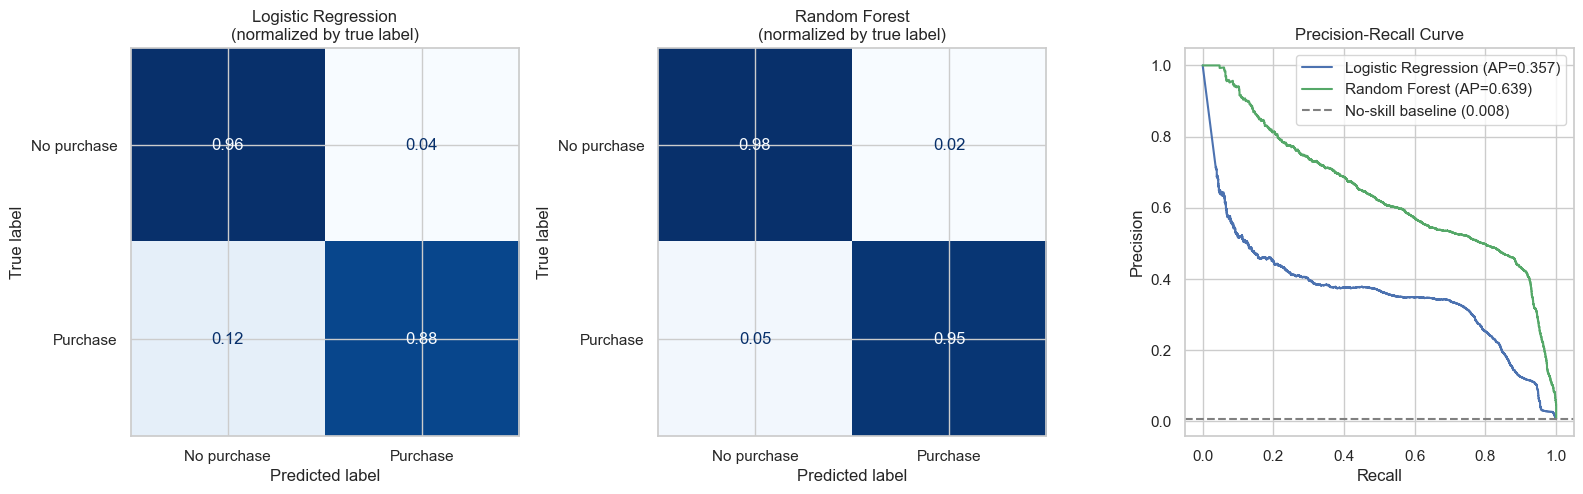

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Normalized confusion matrices ---
for ax, y_pred, label in [
    (axes[0], y_pred_lr, 'Logistic Regression'),
    (axes[1], y_pred_rf, 'Random Forest'),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['No purchase', 'Purchase'],
        normalize='true',          # show recall per class, not raw counts
        ax=ax, colorbar=False, cmap='Blues',
        values_format='.2f',
    )
    ax.set_title(f'{label}\n(normalized by true label)')

# --- Precision-Recall curves ---
for y_prob, label, color in [
    (y_proba_lr, 'Logistic Regression', '#4C72B0'),
    (y_proba_rf, 'Random Forest',        '#55A868'),
]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[2].plot(rec, prec, label=f'{label} (AP={ap:.3f})', color=color)

baseline_rate = y_test.mean()
axes[2].axhline(baseline_rate, linestyle='--', color='grey', label=f'No-skill baseline ({baseline_rate:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()

plt.tight_layout()
plt.show()

In [8]:
results = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'ROC-AUC': roc_auc_score(y_test, y_proba_lr),
        'PR-AUC':  average_precision_score(y_test, y_proba_lr),
        'F1 (purchase)': f1_score(y_test, y_pred_lr),
    },
    {
        'Model': 'Random Forest',
        'ROC-AUC': roc_auc_score(y_test, y_proba_rf),
        'PR-AUC':  average_precision_score(y_test, y_proba_rf),
        'F1 (purchase)': f1_score(y_test, y_pred_rf),
    },
]).set_index('Model')

print(results.round(4))

                     ROC-AUC  PR-AUC  F1 (purchase)
Model                                              
Logistic Regression   0.9739  0.3570         0.2510
Random Forest         0.9942  0.6389         0.4003


## 5. Cross-Validation (5-Fold Stratified)

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['roc_auc', 'average_precision', 'f1']

cv_results = {}
for name, model, X_cv in [
    ('Logistic Regression', lr, X_train_scaled),
    ('Random Forest',        rf, X_train),
]:
    scores = cross_validate(model, X_cv, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'ROC-AUC':       f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        'PR-AUC':        f"{scores['test_average_precision'].mean():.4f} ± {scores['test_average_precision'].std():.4f}",
        'F1 (purchase)': f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
    }

cv_df = pd.DataFrame(cv_results).T
print('5-fold stratified CV — mean ± std:')
print(cv_df)

5-fold stratified CV — mean ± std:
                             ROC-AUC           PR-AUC    F1 (purchase)
Logistic Regression  0.9732 ± 0.0011  0.3377 ± 0.0018  0.2488 ± 0.0025
Random Forest        0.9941 ± 0.0003  0.6239 ± 0.0054  0.4076 ± 0.0050


## 6. Permutation Feature Importance

Permutation importance measures how much the model's PR-AUC drops when a feature's values are randomly shuffled.
This is more reliable than MDI (the default `feature_importances_` in scikit-learn), which systematically
overestimates the importance of high-cardinality numerical features.

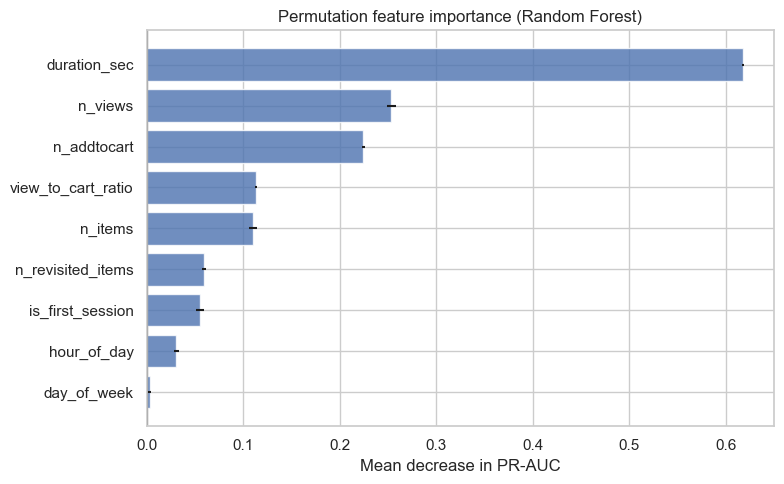

           feature  importance_mean  importance_std
      duration_sec         0.618130        0.001049
           n_views         0.253191        0.004704
       n_addtocart         0.224546        0.001536
view_to_cart_ratio         0.113339        0.001098
           n_items         0.110312        0.004105
 n_revisited_items         0.059509        0.001812
  is_first_session         0.055016        0.003965
       hour_of_day         0.030756        0.003014
       day_of_week         0.003011        0.001405


In [10]:
result_rf = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10,
    scoring='average_precision',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = (
    pd.DataFrame({
        'feature': FEATURES,
        'importance_mean': result_rf.importances_mean,
        'importance_std':  result_rf.importances_std,
    })
    .sort_values('importance_mean', ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm_df['feature'], perm_df['importance_mean'],
        xerr=perm_df['importance_std'], color='#4C72B0', alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean decrease in PR-AUC')
ax.set_title('Permutation feature importance (Random Forest)')
plt.tight_layout()
plt.show()

print(perm_df.sort_values('importance_mean', ascending=False).to_string(index=False))


## 7. Threshold Tuning

The default classification threshold of 0.5 is almost never optimal for imbalanced targets.
We find the threshold that maximises F1 on the test set by sweeping the full precision-recall curve.

Note: in production, threshold tuning should be done on a held-out validation set, not the test set.

Default threshold (0.50):  F1 = 0.4003
Optimal threshold (0.975): F1 = 0.6149

Classification report at optimal threshold:
              precision    recall  f1-score   support

 no purchase       1.00      0.99      1.00    349476
    purchase       0.52      0.75      0.61      2859

    accuracy                           0.99    352335
   macro avg       0.76      0.87      0.81    352335
weighted avg       0.99      0.99      0.99    352335



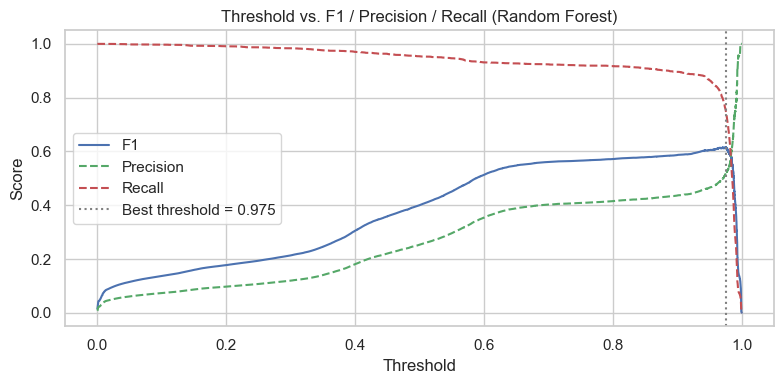

In [11]:
prec, rec, thresholds = precision_recall_curve(y_test, y_proba_rf)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)

best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f'Default threshold (0.50):  F1 = {f1_score(y_test, y_pred_rf):.4f}')
print(f'Optimal threshold ({best_threshold:.3f}): F1 = {best_f1:.4f}')

y_pred_tuned = (y_proba_rf >= best_threshold).astype(int)
print('\nClassification report at optimal threshold:')
print(classification_report(y_test, y_pred_tuned, target_names=['no purchase', 'purchase']))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_scores[:-1], color='#4C72B0', label='F1')
ax.plot(thresholds, prec[:-1],  color='#55A868', linestyle='--', label='Precision')
ax.plot(thresholds, rec[:-1],   color='#C44E52', linestyle='--', label='Recall')
ax.axvline(best_threshold, color='grey', linestyle=':',
           label=f'Best threshold = {best_threshold:.3f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold vs. F1 / Precision / Recall (Random Forest)')
ax.legend()
plt.tight_layout()
plt.show()


## Summary & Interpretation

### Results

| Model | ROC-AUC | PR-AUC | F1 (purchase, threshold=0.5) |
|-------|---------|--------|------------------------------|
| Logistic Regression | 0.9739 | 0.3570 | 0.2510 |
| Random Forest | **0.9942** | **0.6389** | **0.4003** |

5-fold CV (mean ± std — confirms the test-set numbers are stable, not a lucky split):

| Model | ROC-AUC | PR-AUC | F1 |
|-------|---------|--------|----|
| Logistic Regression | 0.9732 ± 0.0011 | 0.3377 ± 0.0018 | 0.2488 ± 0.0025 |
| Random Forest | 0.9941 ± 0.0003 | 0.6239 ± 0.0054 | 0.4076 ± 0.0050 |

Random Forest after threshold tuning (threshold = 0.975):

| Precision | Recall | F1 |
|-----------|--------|----|
| 0.52 | 0.75 | **0.615** |

---

### Interpretation

#### ROC-AUC looks great — but don't be fooled

Both models show ~0.97–0.99 ROC-AUC. For a heavily imbalanced dataset (1:122), this metric is well-known
to be misleading. With 349,476 negatives and only 2,859 positives, even a mediocre probability ranking
produces a high ROC-AUC because the vast majority of (positive, negative) pairs are easy to rank correctly.
**PR-AUC is the metric that actually matters here.** It focuses on the minority class and penalises false positives.

#### PR-AUC: Random Forest is clearly better, but not perfect

The no-skill baseline (always predict the mean) is 0.0081.
- Logistic Regression: PR-AUC = 0.357 — 44× above baseline, but precision stays low across most thresholds.
- Random Forest: PR-AUC = 0.639 — substantially better. The model has genuine predictive power.

A PR-AUC of 0.64 is a real result, not noise. But it also means ~36 % of the area under a perfect curve
is missing — the model still makes a lot of mistakes on the minority class.

#### At the default threshold (0.50), precision is only 25 %

With `class_weight='balanced'`, the model is trained to recall buyers at the cost of precision.
At threshold = 0.50, the Random Forest correctly identifies 95 % of buyers (recall),
but 3 out of every 4 predicted "purchases" are wrong (precision = 25 %).

#### Threshold tuning: the optimal is 0.975

The model only predicts "purchase" when its confidence exceeds 97.5 %.
- Recall drops from 95 % to 75 % — we miss a quarter of buyers.
- Precision rises from 25 % to 52 % — more than half the predictions are now correct.
- F1 improves from 0.40 to 0.615.

The fact that the optimal threshold is so high (0.975) indicates the model's probability estimates are
not well-calibrated for the purchase class — it rarely assigns very high scores to actual buyers.
Probability calibration (Platt scaling / isotonic regression) would be a useful next step.

#### Feature importance: duration_sec dominates — but be careful

`duration_sec` is by far the most important feature (0.618), nearly 3× more than `n_addtocart` (0.224).
This is partly expected — engaged sessions last longer. But there is also a circular component:
sessions that contain a transaction are necessarily longer because checkout events happen at the end.
`duration_sec` is not future leakage in the strict sense, but it is partly a *consequence* of purchasing,
not only a predictor. In a real-time scoring scenario (scoring a session mid-way), the final duration
is not yet available — this feature would be less useful in production.

`day_of_week` has near-zero importance (0.003, within the noise of the std 0.001).
It contributes nothing and can be dropped.

#### What this model can and cannot do

**It can** rank sessions by purchase likelihood. At the optimal threshold, precision is 52 % vs.
a base rate of 0.81 % — a ~64× lift over random. This is useful for targeting interventions
(e.g., showing a discount to sessions most likely to convert).

**It cannot** reliably classify individual sessions. Even at best, 48 % of predicted buyers will not buy,
and 25 % of actual buyers are missed. It is a ranking tool, not a reliable binary classifier.

#### Possible improvements

- Remove `day_of_week` (zero importance).
- Investigate `duration_sec` leakage: cap duration at a point before session end, or exclude it and compare PR-AUC.
- Try gradient boosting (XGBoost / LightGBM) — typically stronger than RF on tabular data.
- Apply probability calibration to get better-calibrated confidence scores.
- Add item-category features from the `item_properties` files (product type, price range).